In [1]:
import pandas as pd
import numpy as np
from src.utils.DataHandler import *
from pathlib import Path
import os


from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from config import paths

          Ftr1       Ftr2      Ftr3      Ftr4      Ftr5      Ftr6      Ftr7  \
0    -3.585287   1.690334 -5.008367 -1.276874  2.201695 -2.052844 -1.936174   
1     5.269343   3.653372  4.676558  2.236624 -4.007261  4.621730 -1.368541   
2    -7.940669   2.173178 -2.738962 -7.498355 -1.816149  2.577167  9.748079   
3     0.823099  -0.069443 -0.371985  6.265540 -1.903001  2.713673  0.942170   
4     9.189330   1.902139  9.236811 -1.013560  1.208134  3.978239 -8.361322   
...        ...        ...       ...       ...       ...       ...       ...   
9161  2.012246  11.932792  0.618674 -0.666053  0.878676  1.077506 -3.505408   
9162 -5.476591   4.795226  4.406340 -7.731936  0.444616 -0.893707 -2.956735   
9163  9.989466   5.730635  0.326629 -4.239403  7.264786 -3.255078  0.125781   
9164 -0.603208   7.878872  6.773109 -1.984896 -1.783690  2.604709 -6.338108   
9165 -2.143748  -0.617564  5.221180  6.690803 -1.713349  2.234750 -1.003183   

          Ftr8      Ftr9     Ftr10  label  
0    -2

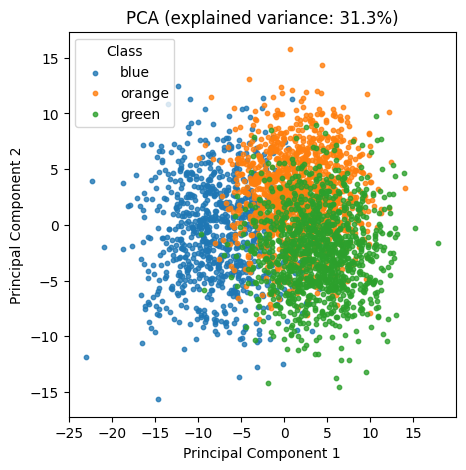


    Training set distribution: {0: 1773, 1: 2317, 2: 2326}
    Validation set distribution: {0: 880, 1: 1156, 2: 1172}
    Test set distribution: {0: 893, 1: 1161, 2: 1154}
    


In [ ]:
# random blobs with more overlap -- more difficult to classify, and higher dimensionality (10D)
n_classes = 3
n_features = 10

# Custom centers in 10D: orange and green close, blue a bit closer with more spread
custom_centers = [
    [-3, 1, -2, 1, 3, -1, 1, 2, -1, 0],    # blue - etwas näher ran
    [1, 4, 2, -1, 0, 3, -2, 1, 2, -1],      # orange - Mitte
    [4, 0, 3, -2, 1, 2, -1, 0, 3, -2],       # green - close to orange
]

# Make train and test data
X, y = make_blobs(n_samples=10000, n_features=n_features, centers=custom_centers,
                  cluster_std=[4.5, 3.75, 3.75], random_state=42)

# Reduce the size of the first class to create an imbalanced dataset
np.random.seed(42)
class_0_idx = np.where(y == 0)[0]
class_0_idx = np.random.choice(class_0_idx, int(len(class_0_idx) * 0.75), replace=False)
rest_idx = np.where(y != 0)[0]
idx = np.concatenate([class_0_idx, rest_idx])
np.random.shuffle(idx)
X = X[idx]
y = y[idx]
data = pd.DataFrame(X, columns=[f'Ftr{i+1}' for i in range(n_features)])
data['label'] = y
print(data)

# Split off model training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# Split rest into calibration and test
X_val, X_test, y_val, y_test = train_test_split(X_train, y_train, test_size=0.5, random_state=42)

# Set class labels
class_labels = ['blue', 'orange', 'green']

# PCA for visualization
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca.fit(X_train)
X_test_pca = pca.transform(X_test)

# Plot PCA
fig = plt.subplots(figsize=(5, 5))
ax = plt.subplot(111)
for i in range(n_classes):
    ax.scatter(X_test_pca[y_test == i, 0], X_test_pca[y_test == i, 1],
               label=class_labels[i], alpha=0.8, s=10)
legend = ax.legend()
legend.set_title("Class")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title(f"PCA (explained variance: {pca.explained_variance_ratio_.sum():.1%})")
plt.show()

unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_val, counts_val = np.unique(y_val, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)
print(f"""
    Training set distribution: {dict(zip(unique_train, counts_train))}
    Validation set distribution: {dict(zip(unique_val, counts_val))}
    Test set distribution: {dict(zip(unique_test, counts_test))}
    """)

## Save the data to CSV
data.to_csv("./artifacts/data/datasets/random_blobs_data_balanced.csv", index=False)

## Prepare Steel Plates Dataset

In [2]:
from config import paths

# Datensatz laden
DATA_PATH = paths.BASE_DIR / "artifacts" / "data" / "datasets" / "faulty_steelplates.csv"
data_raw = pd.read_csv(DATA_PATH)

print(f"Shape: {data_raw.shape}")
print(f"Spalten: {data_raw.columns.tolist()}")
print(data_raw.head())

Shape: (1941, 34)
Spalten: ['X_Minimum', 'X_Maximum', 'Y_Minimum', 'Y_Maximum', 'Pixels_Areas', 'X_Perimeter', 'Y_Perimeter', 'Sum_of_Luminosity', 'Minimum_of_Luminosity', 'Maximum_of_Luminosity', 'Length_of_Conveyer', 'TypeOfSteel_A300', 'TypeOfSteel_A400', 'Steel_Plate_Thickness', 'Edges_Index', 'Empty_Index', 'Square_Index', 'Outside_X_Index', 'Edges_X_Index', 'Edges_Y_Index', 'Outside_Global_Index', 'LogOfAreas', 'Log_X_Index', 'Log_Y_Index', 'Orientation_Index', 'Luminosity_Index', 'SigmoidOfAreas', 'Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
   X_Minimum  X_Maximum  Y_Minimum  Y_Maximum  Pixels_Areas  X_Perimeter  \
0         42         50     270900     270944           267           17   
1        645        651    2538079    2538108           108           10   
2        829        835    1553913    1553931            71            8   
3        853        860     369370     369415           176           13   
4       1289       1306    

In [3]:
###### Steel Plates Faults Dataset - Laden und Vorbereiten
import pandas as pd
import numpy as np

# Datensatz laden
DATA_PATH = paths.BASE_DIR / "artifacts" / "data" / "datasets" / "faulty_steelplates.csv"
data_raw = pd.read_csv(DATA_PATH)

# One-Hot Labels und Features trennen
fault_types = ['Pastry', 'Z_Scratch', 'K_Scatch', 'Stains', 'Dirtiness', 'Bumps', 'Other_Faults']
feature_cols = [c for c in data_raw.columns if c not in fault_types]

X = data_raw[feature_cols]
y_single = data_raw[fault_types].idxmax(axis=1)
y_single.name = 'fault_type'

# Gesamter Datensatz mit Original-Labels
data_original = pd.concat([X, y_single], axis=1)
print("=== Original-Verteilung (7 Klassen) ===")
print(data_original['fault_type'].value_counts().sort_index())
print(f"Gesamt: {len(data_original)} Samples\n")

# -------------------------------------------------------
# Variante 1: 4-Klassen-Gruppierung
# -------------------------------------------------------
mapping_4 = {
    'Stains':       0,  # Kosmetisch
    'Dirtiness':    0,  # Kosmetisch
    'Pastry':       1,  # Leichte Oberflächendefekte
    'Bumps':        1,  # Leichte Oberflächendefekte
    'Z_Scratch':    2,  # Kratzer/Risse
    'K_Scatch':     2,  # Kratzer/Risse
    'Other_Faults': 3,  # Sonstige / Unklar
}
label_names_4 = {0: 'Kosmetisch', 1: 'Oberflaechendefekt', 2: 'Kratzer', 3: 'Sonstige'}

data_4cls = pd.concat([X, y_single], axis=1).copy()
data_4cls['label'] = data_4cls['fault_type'].map(mapping_4)
data_4cls['label_name'] = data_4cls['label'].map(label_names_4)
data_4cls = data_4cls.drop(columns=['fault_type'])

print("=== 4-Klassen-Verteilung ===")
for label, name in sorted(label_names_4.items()):
    count = (data_4cls['label'] == label).sum()
    print(f"  Klasse {label} ({name}): {count}")
print()

# -------------------------------------------------------
# Variante 2: 3-Klassen-Gruppierung
# -------------------------------------------------------
mapping_3 = {
    'Stains':       0,  # Kleines Reparaturprogramm
    'Dirtiness':    0,  # Kleines Reparaturprogramm
    'Pastry':       0,  # Kleines Reparaturprogramm
    'Bumps':        1,  # Größeres Reparaturprogramm
    'Z_Scratch':    1,  # Größeres Reparaturprogramm
    'K_Scatch':     1,  # Größeres Reparaturprogramm
    'Other_Faults': 2,  # Verschrottung / Neufertigung
}
label_names_3 = {0: 'Kleines_Reparaturprogramm', 1: 'Grosses_Reparaturprogramm', 2: 'Verschrottung'}

data_3cls = pd.concat([X, y_single], axis=1).copy()
data_3cls['label'] = data_3cls['fault_type'].map(mapping_3)
data_3cls['label_name'] = data_3cls['label'].map(label_names_3)
data_3cls = data_3cls.drop(columns=['fault_type'])

print("=== 3-Klassen-Verteilung ===")
for label, name in sorted(label_names_3.items()):
    count = (data_3cls['label'] == label).sum()
    print(f"  Klasse {label} ({name}): {count}")
print()

# -------------------------------------------------------
# Speichern
# -------------------------------------------------------
save_dir = paths.BASE_DIR / "artifacts" / "data" / "datasets"
#data_4cls.to_csv(save_dir / "steel_plates_4cls.csv", index=False)

# drop columns 'label_name' and 'fault_type' before saving, to keep only numeric labels
data_3cls = data_3cls.drop(columns=['label_name'])
data_3cls.to_csv(save_dir / "steel_plates_3cls.csv", index=False)
print("Gespeichert:")
print(f"  → {save_dir / 'steel_plates_4cls.csv'}")
print(f"  → {save_dir / 'steel_plates_3cls.csv'}")


=== Original-Verteilung (7 Klassen) ===
fault_type
Bumps           402
Dirtiness        55
K_Scatch        391
Other_Faults    673
Pastry          158
Stains           72
Z_Scratch       190
Name: count, dtype: int64
Gesamt: 1941 Samples

=== 4-Klassen-Verteilung ===
  Klasse 0 (Kosmetisch): 127
  Klasse 1 (Oberflaechendefekt): 560
  Klasse 2 (Kratzer): 581
  Klasse 3 (Sonstige): 673

=== 3-Klassen-Verteilung ===
  Klasse 0 (Kleines_Reparaturprogramm): 285
  Klasse 1 (Grosses_Reparaturprogramm): 983
  Klasse 2 (Verschrottung): 673

Gespeichert:
  → /home/kristinadachtler/Notebooks/Goal-orientedML/artifacts/data/datasets/steel_plates_4cls.csv
  → /home/kristinadachtler/Notebooks/Goal-orientedML/artifacts/data/datasets/steel_plates_3cls.csv
